# MIMIC-III -- ICU Length-of-Stay Prediction

**Course project -- Big Data.** Predict a patient's **ICU length of stay (LOS, in days)**
from the **first 24 hours** of bedside chart events.

This notebook is the orchestrator; all logic lives in the `src/` package so it is
testable and reusable. The design goals, in order:

1. **Handle the data at scale.** CHARTEVENTS has ~330M rows (4.2 GB compressed). We never
   download it -- the cohort selection, first-window filtering, error/range cleaning,
   CareVue<->MetaVision ITEMID harmonization and per-concept aggregation are all pushed into
   **BigQuery SQL**; only a compact aggregated table comes back.
2. **No leakage.** Features use *only* the first-24h window; the split is **grouped by
   `SUBJECT_ID`**; preprocessing is fit inside CV folds.
3. **Honest evaluation.** LOS is genuinely hard -- the literature reports low R^2 for
   continuous LOS, so we report it *and* the more standard bucketed classification, against
   trivial baselines, and we profile every phase.

> **Target = ICU LOS in days** (`ICUSTAYS.OUTTIME - INTIME`), one row per `ICUSTAY_ID`.
> We predict *at the 24h mark*, so the cohort is stays still in the ICU at 24h
> (`MIN_LOS_HOURS = 24`).

## 0. Environment & configuration

In [10]:
import logging, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# make `src` importable
sys.path.insert(0, str(Path.cwd()))

from src import config as cfg
from src.data.loader import load_cohort
from src.data import sql, synthetic
from src.features.engineering import build_feature_matrix
from src.data.splits import grouped_train_test_split, assert_no_group_leakage
from src.models import registry
from src.evaluation import harness, metrics
from src.evaluation.profiling import Profiler
from src.visualization import plots

# Set to True to run against your BigQuery project (needs gcp_key.json + the
# tables loaded via import_tables.py). False -> labelled synthetic fallback.
USE_BIGQUERY = True

profiler = Profiler()
print("config:", f"window={cfg.PREDICTION_WINDOW_HOURS}h",
      f"min_los={cfg.MIN_LOS_HOURS}h", f"buckets<{cfg.LOS_SHORT_DAYS}/<{cfg.LOS_MEDIUM_DAYS}d")
print("credentials found:", cfg.GCP_CREDENTIALS_PATH or "none (will use synthetic)")

config: window=24h min_los=24h buckets<3/<7d
credentials found: ./gcp_key.json


## 1. Load data -- BigQuery first, synthetic fallback

`load_cohort` runs three SQL jobs (cohort+target, first-window aggregates, demographics)
when BigQuery is available, otherwise it returns an identically-shaped **synthetic** cohort
so the notebook always runs. The aggregation SQL is shown below -- note the leakage controls
in the `WHERE` clause (`charttime < intime + 24h`, `error = 0`, per-concept range filter).

In [11]:
print(sql.window_aggregates_query(cfg.PREDICTION_WINDOW_HOURS, limit=cfg.DEV_ICUSTAY_LIMIT))

WITH concept_map AS (
    SELECT * FROM UNNEST([
        STRUCT(211 AS itemid, 'heart_rate' AS concept, 10.0 AS lo, 300.0 AS hi),
        STRUCT(220045 AS itemid, 'heart_rate' AS concept, 10.0 AS lo, 300.0 AS hi),
        STRUCT(51 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(442 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(455 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(6701 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(220179 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(220050 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(8368 AS itemid, 'dbp' AS concept, 5.0 AS lo, 200.0 AS hi),
        STRUCT(8440 AS itemid, 'dbp' AS concept, 5.0 AS lo, 200.0 AS hi),
        STRUCT(8441 AS itemid, 'dbp' AS concept, 5.0 AS lo, 200.0 AS hi),
        STRUCT(8555 AS itemid, 'dbp' AS concept, 5.0 AS lo, 200.0 AS hi),
        STRUCT(220180 AS itemid, 'dbp' A

In [12]:
with profiler.track("1_load_data"):
    data = load_cohort(use_bigquery=USE_BIGQUERY,
                       window_hours=cfg.PREDICTION_WINDOW_HOURS,
                       limit=cfg.DEV_ICUSTAY_LIMIT)

banner = "REAL MIMIC-III via BigQuery" if data.is_real else \
    "(!)  SYNTHETIC DATA -- results below are a DEMONSTRATION, not real findings (!)"
print("=" * 72, f"\nDATA SOURCE: {data.source}  ({banner})\n", "=" * 72, sep="")
print("cohort      :", data.cohort.shape)
print("aggregates  :", data.aggregates.shape, "(long: icustay x concept)")
print("demographics:", data.demographics.shape)
data.cohort.head()

INFO | [start] 1_load_data
INFO | BigQuery unavailable (no client or no credentials).
WARNING | Using SYNTHETIC data -- results are for demonstration only.
INFO | [done ] 1_load_data (0.43s)


DATA SOURCE: SYNTHETIC  ((!)  SYNTHETIC DATA -- results below are a DEMONSTRATION, not real findings (!))
cohort      : (4000, 5)
aggregates  : (37244, 7) (long: icustay x concept)
demographics: (4000, 10)


,icustay_id,subject_id,hadm_id,intime,los_icu_days
0,200000,10254,100907,2150-01-01,2.217458
1,200001,12211,102407,2150-01-01,1.000000
2,200002,11870,100100,2150-01-01,8.634432
3,200003,11253,101275,2150-01-01,13.616450
4,200004,11237,102288,2150-01-01,1.731782


## 2. Exploratory data analysis

### 2.1 Per-patient event timeline
Reproduces the assignment's example plot: time since ICU admission (in days) vs measured
value, coloured by harmonized concept. On the BigQuery path this is one real stay; on the
synthetic path it is an illustrative stream.

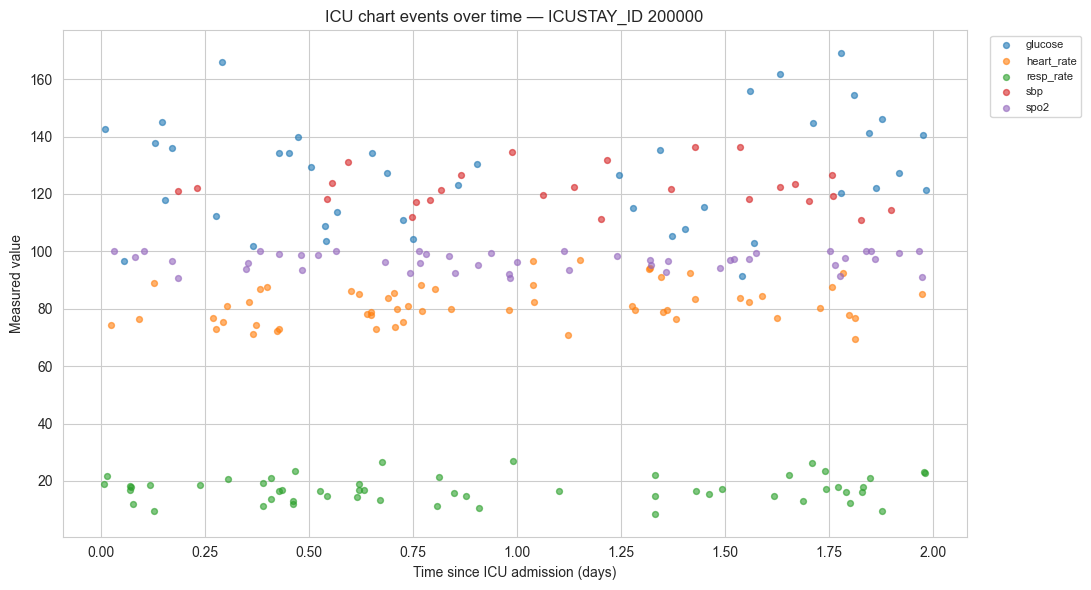

227 measurements across 5 concepts for stay 200000


In [13]:
example_id = int(data.cohort["icustay_id"].iloc[0])
if data.is_real:
    from src.data.loader import BigQueryClient
    tl = BigQueryClient().run(sql.patient_timeline_query(example_id, window_hours=48),
                              f"timeline_{example_id}")
else:
    tl = synthetic.patient_timeline(example_id, window_hours=48)

fig = plots.patient_timeline(tl, example_id)
plots.save(fig, f"patient_timeline_{example_id}.png"); plt.show()
print(f"{len(tl)} measurements across {tl['concept'].nunique()} concepts for stay {example_id}")

### 2.2 Target distribution and class balance

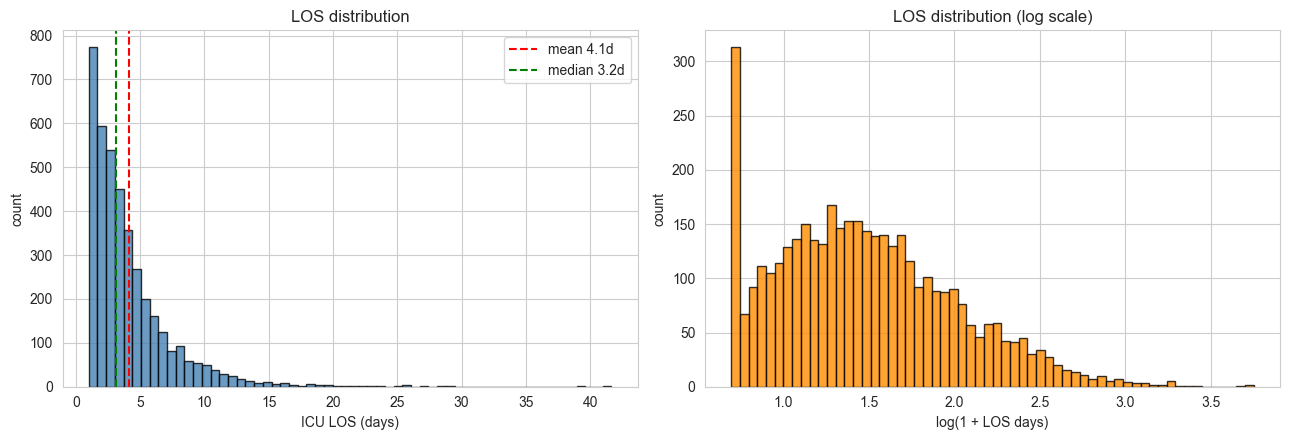

ICU LOS (days):
count    4000.00
mean        4.11
std         3.38
min         1.00
25%         1.94
50%         3.15
75%         5.12
max        41.65

The distribution is strongly right-skewed -- most stays are short, a long tail of complex patients. This skew is exactly why LOS is hard to predict and why we also evaluate a bucketed classification framing.


In [14]:
y_days = data.cohort["los_icu_days"].clip(upper=cfg.MAX_LOS_DAYS)
fig = plots.los_distribution(y_days); plots.save(fig, "los_distribution.png"); plt.show()

print("ICU LOS (days):")
print(y_days.describe().round(2).to_string())
print("\nThe distribution is strongly right-skewed -- most stays are short, a long tail of "
      "complex patients. This skew is exactly why LOS is hard to predict and why we also "
      "evaluate a bucketed classification framing.")

## 3. Feature engineering (leak-free)

`build_feature_matrix`:
* pivots the long aggregates to one column per **concept x {mean,min,max,std,count}**;
* adds two *window-capped* intensity features (`n_measurements_total`, `n_concepts_observed`)
  -- legitimate severity proxies, **not** stay-length proxies because the window is fixed;
* encodes demographics, **clipping age to 90** to neutralise MIMIC's >89y / ~300y DOB shift;
* drops columns missing in >60% of stays;
* leaves remaining NaNs for the in-pipeline imputer (no global imputation -> no leakage).

In [15]:
with profiler.track("2_feature_engineering"):
    fm = build_feature_matrix(data)

print("feature matrix:", fm.X.shape)
print("missing fraction (mean over cols):", round(float(fm.X.isna().mean().mean()), 3))
print("\nexample features:", fm.feature_names[:12], "...")
fm.X.head()

INFO | [start] 2_feature_engineering
INFO | Dropping 10 high-missing features: ['temp_c_count', 'temp_c_max', 'temp_c_mean', 'temp_c_min', 'temp_c_std', 'tidal_volume_count', 'tidal_volume_max', 'tidal_volume_mean', 'tidal_volume_min', 'tidal_volume_std']
INFO | Feature matrix: 4000 stays x 71 features | LOS mean=4.11 median=3.15 days
INFO | Class balance: {'short': 1880, 'medium': 1580, 'long': 540}
INFO | [done ] 2_feature_engineering (0.04s)


feature matrix: (4000, 71)
missing fraction (mean over cols): 0.158

example features: ['dbp_mean', 'fio2_mean', 'gcs_total_mean', 'glucose_mean', 'heart_rate_mean', 'mbp_mean', 'resp_rate_mean', 'sbp_mean', 'spo2_mean', 'temp_f_mean', 'weight_kg_mean', 'dbp_min'] ...


,dbp_mean,fio2_mean,gcs_total_mean,glucose_mean,heart_rate_mean,mbp_mean,resp_rate_mean,sbp_mean,spo2_mean,temp_f_mean,...,admission_type_NEWBORN,admission_type_URGENT,first_careunit_CCU,first_careunit_CSRU,first_careunit_MICU,first_careunit_SICU,first_careunit_TSICU,insurance_Medicaid,insurance_Medicare,insurance_Private
icustay_id,,,,,,,,,,,,,,,,,,,,,
200000,70.890968,21.052290,15.000000,89.002113,65.952148,87.898666,9.170760,NaN,100.000000,96.698914,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
200001,68.966286,14.365322,NaN,NaN,69.905136,88.139145,6.595786,138.919220,100.000000,95.488060,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
200002,63.847481,71.020592,4.510796,174.638062,91.789009,70.688095,26.645639,109.255089,96.580345,98.921745,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
200003,62.526058,79.541145,4.310765,NaN,109.619995,70.625648,31.817736,95.460205,85.228951,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
200004,69.068192,27.127766,15.000000,111.925957,78.280663,87.062790,14.451964,125.341347,99.133308,98.000366,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 4. Train / test split -- grouped by SUBJECT_ID

A patient can have several ICU stays. A random split would leak patient-specific signal
across train/test. We use `GroupShuffleSplit` on `SUBJECT_ID` and assert no patient straddles
the split. We also encode the ordinal LOS buckets (short<medium<long) as 0/1/2.

In [16]:
X_tr, X_te, y_tr, y_te, g_tr, g_te = grouped_train_test_split(
    fm.X, fm.y_reg, fm.groups)
assert_no_group_leakage(g_tr, g_te)

CODE = {"short": 0, "medium": 1, "long": 2}
INV = {v: k for k, v in CODE.items()}
yc = fm.y_clf.map(CODE)
yc_tr, yc_te = yc.loc[y_tr.index], yc.loc[y_te.index]

print(f"train: {X_tr.shape[0]} stays / {g_tr.nunique()} patients")
print(f"test : {X_te.shape[0]} stays / {g_te.nunique()} patients")
print("no patient overlap between train and test (ok)")
print("\nclass balance (train):", yc_tr.map(INV).value_counts().to_dict())

train: 3200 stays / 1704 patients
test : 800 stays / 426 patients
no patient overlap between train and test (ok)

class balance (train): {'short': 1501, 'medium': 1266, 'long': 433}


## 5. Regression -- model comparison (GroupKFold CV)

All models are plain scikit-learn `Pipeline`s (impute -> [scale] -> estimator) so
preprocessing is fit per fold. We compare a **mean baseline**, Ridge, Random Forest,
HistGradientBoosting, XGBoost and LightGBM under 5-fold **GroupKFold**.

INFO | [start] 3_regression_cv
INFO | [done ] 3_regression_cv (18.22s)


,MAE_mean,MAE_std,RMSE_mean,R2_mean,fit_time_s
random_forest,1.885,0.048,2.880,0.302,4.661
ridge,1.920,0.073,2.906,0.290,0.013
xgboost,1.958,0.043,3.000,0.242,2.213
hist_gb,1.984,0.049,3.051,0.215,1.197
lightgbm,1.985,0.058,3.051,0.215,2.298
baseline_mean,2.336,0.052,3.447,-0.001,0.010


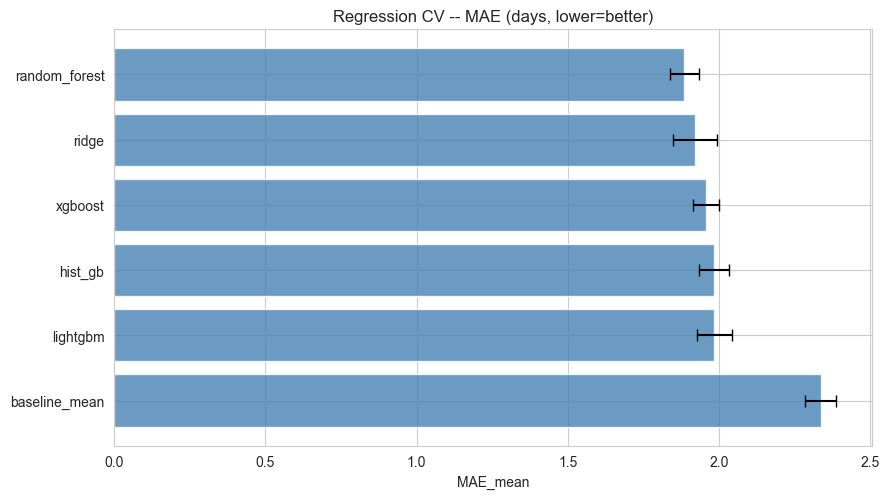

Baseline_mean ~ 0 R^2 confirms the target isn't trivially leaked -- any lift over it is real signal.


In [17]:
with profiler.track("3_regression_cv"):
    reg_cv = harness.cross_validate_models(
        registry.build_regressors(), X_tr, y_tr, g_tr, "regression")

display(reg_cv[["MAE_mean", "MAE_std", "RMSE_mean", "R2_mean", "fit_time_s"]].round(3))
fig = plots.model_comparison(reg_cv, "MAE_mean", "Regression CV -- MAE (days, lower=better)",
                             lower_is_better=True)
plots.save(fig, "reg_model_comparison.png"); plt.show()
print("Baseline_mean ~ 0 R^2 confirms the target isn't trivially leaked -- any lift over it is real signal.")

## 6. Regression -- hyper-parameter search + hold-out evaluation

In [18]:
with profiler.track("4_hp_search"):
    tuned_name, tuned_model, best_params, cv_mae = harness.tune_regressor(
        X_tr, y_tr, g_tr)
print(f"Tuned model: {tuned_name} | CV MAE = {cv_mae:.3f} days")
print("best params:", best_params)

INFO | [start] 4_hp_search
INFO | [done ] 4_hp_search (61.46s)


Tuned model: lightgbm | CV MAE = 1.874 days
best params: {'model__subsample': 0.8, 'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 40, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


INFO | [start] 5_holdout_eval
INFO | [done ] 5_holdout_eval (0.31s)


HOLD-OUT regression -- lightgbm (fit 0.3s)
  MAE       : 1.799
  RMSE      : 2.571
  R2        : 0.291
  MedAE     : 1.299
  within_1d : 0.388
  within_2d : 0.701


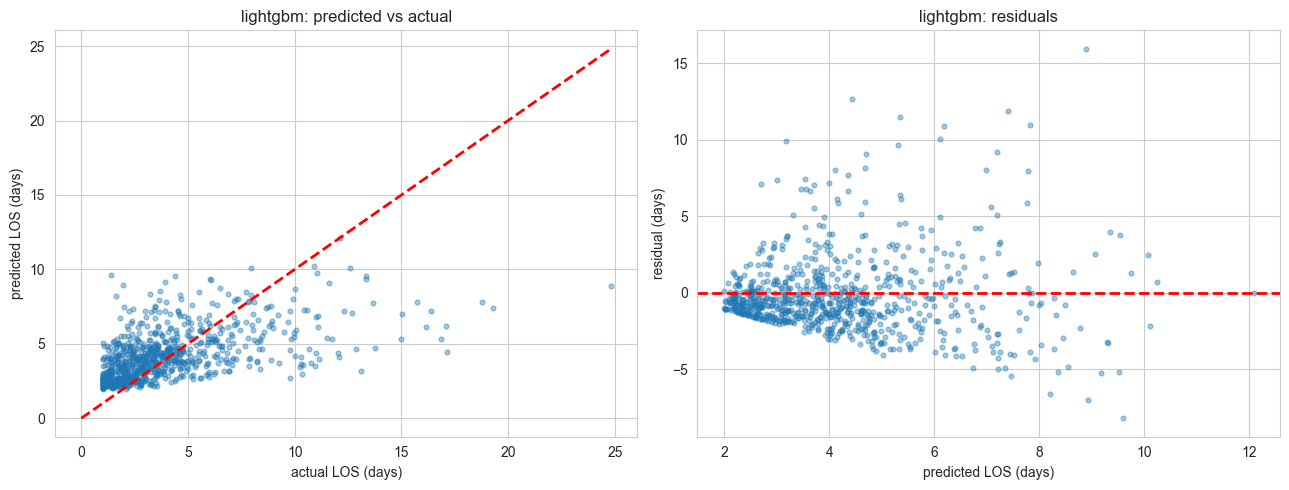


Error by true-LOS band (where does it fail?):


,LOS_range_days,n,MAE,mean_pred,mean_true
0,0-2,211,1.68,3.14,1.46
1,2-5,389,1.21,4.14,3.27
2,5-10,154,2.00,5.33,6.85
3,10-20,45,6.42,6.21,12.63
4,20-inf,1,15.93,8.89,24.81


In [19]:
with profiler.track("5_holdout_eval"):
    y_pred, _, fit_s = harness.holdout_fit_predict(tuned_model, X_tr, y_tr, X_te)

m = metrics.regression_metrics(y_te, y_pred)
print(f"HOLD-OUT regression -- {tuned_name} (fit {fit_s:.1f}s)")
for k, v in m.items():
    print(f"  {k:10s}: {v:.3f}")

fig = plots.predicted_vs_actual(y_te, y_pred, tuned_name)
plots.save(fig, "reg_pred_vs_actual.png"); plt.show()

print("\nError by true-LOS band (where does it fail?):")
display(metrics.error_by_los_range(y_te, y_pred).round(2))

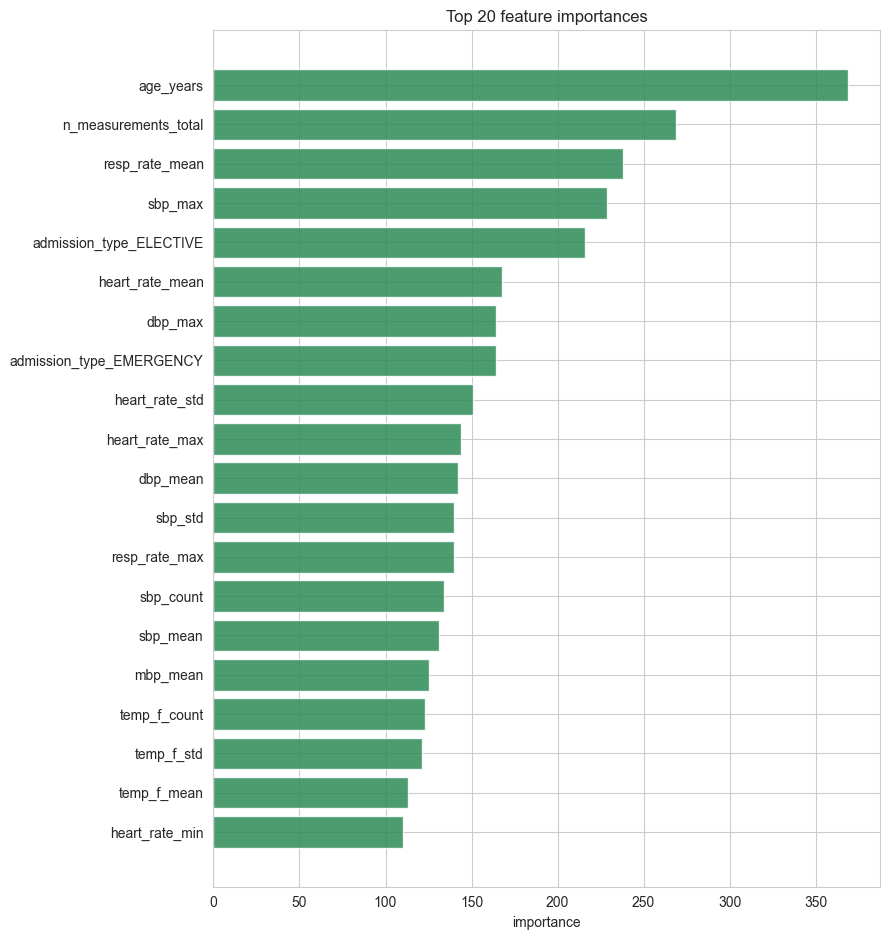

In [20]:
# feature importance from the tuned tree model
est = tuned_model.named_steps["model"]
if hasattr(est, "feature_importances_"):
    fig = plots.feature_importance(list(fm.feature_names), est.feature_importances_, top_n=20)
    plots.save(fig, "feature_importance.png"); plt.show()

## 7. Classification -- short (<3d) / medium (3-7d) / long (>7d)

The literature usually frames LOS as ordinal classification (clearer metrics, robust to
the long tail). Class imbalance is handled with balanced class weights. We report accuracy,
macro-F1, **quadratic-weighted Cohen's kappa** (rewards near-misses on the ordinal scale) and
one-vs-rest macro AUROC.

INFO | [start] 6_classification_cv
INFO | [done ] 6_classification_cv (16.29s)


,accuracy_mean,f1_macro_mean,kappa_quadratic_mean,roc_auc_ovr_mean
logistic,0.573,0.540,0.510,0.757
random_forest,0.599,0.549,0.503,0.760
hist_gb,0.573,0.515,0.454,0.735
xgboost,0.591,0.512,0.454,0.750
lightgbm,0.573,0.512,0.443,0.738
baseline_majority,0.469,0.213,0.000,0.500


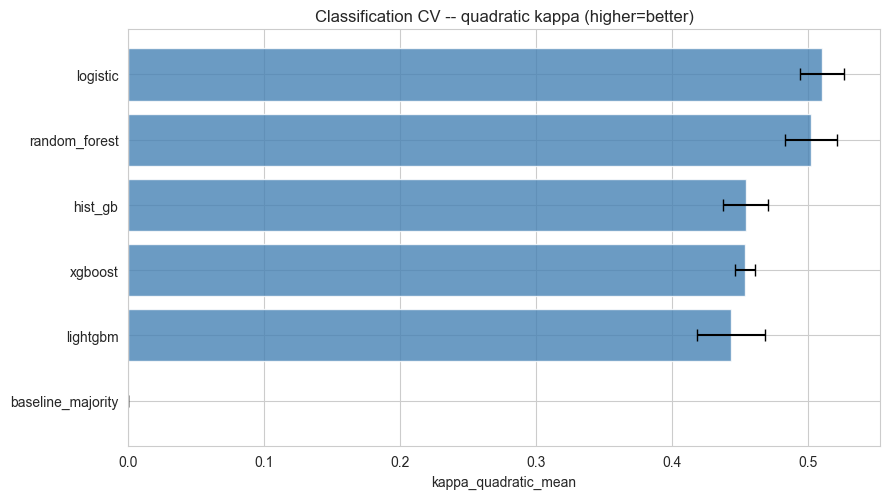

In [21]:
with profiler.track("6_classification_cv"):
    clf_cv = harness.cross_validate_models(
        registry.build_classifiers(), X_tr, yc_tr, g_tr, "classification")

display(clf_cv[["accuracy_mean", "f1_macro_mean", "kappa_quadratic_mean",
                "roc_auc_ovr_mean"]].round(3))
fig = plots.model_comparison(clf_cv, "kappa_quadratic_mean",
                             "Classification CV -- quadratic kappa (higher=better)",
                             lower_is_better=False)
plots.save(fig, "clf_model_comparison.png"); plt.show()

HOLD-OUT classification -- logistic
  accuracy        : 0.547
  f1_macro        : 0.523
  precision_macro : 0.517
  recall_macro    : 0.571
  kappa_quadratic : 0.477
  roc_auc_ovr     : 0.749

               precision    recall  f1-score   support

        long       0.34      0.68      0.46       107
      medium       0.49      0.39      0.44       314
       short       0.71      0.64      0.67       379

    accuracy                           0.55       800
   macro avg       0.52      0.57      0.52       800
weighted avg       0.58      0.55      0.55       800



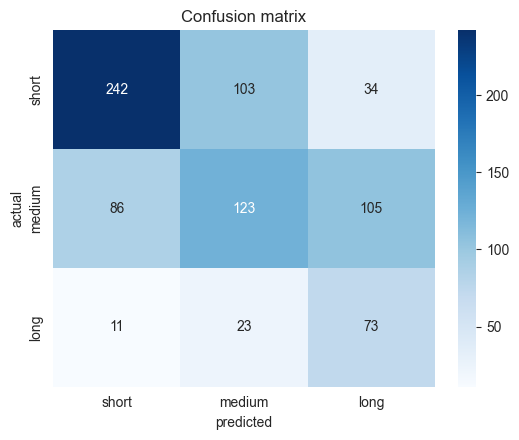

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

best_clf_name = clf_cv.index[0]
best_clf = registry.build_classifiers()[best_clf_name]
yc_pred, yc_proba, _ = harness.holdout_fit_predict(best_clf, X_tr, yc_tr, X_te, want_proba=True)

labels = [0, 1, 2]
cm_metrics = metrics.classification_metrics(yc_te, yc_pred, yc_proba, labels=labels)
print(f"HOLD-OUT classification -- {best_clf_name}")
for k, v in cm_metrics.items():
    print(f"  {k:16s}: {v:.3f}")

print("\n", classification_report(yc_te.map(INV), pd.Series(yc_pred, index=yc_te.index).map(INV),
                                   zero_division=0))
cm = confusion_matrix(yc_te, yc_pred, labels=labels)
fig = plots.confusion(cm, [INV[i] for i in labels]); plots.save(fig, "confusion_matrix.png"); plt.show()

## 8. Performance & profiling

The assignment requires reporting total execution time and profiling the ML phases.

,phase,seconds,pct
0,4_hp_search,61.459600,63.5
1,3_regression_cv,18.223537,18.8
2,6_classification_cv,16.287340,16.8
3,1_load_data,0.429308,0.4
4,5_holdout_eval,0.310924,0.3
5,2_feature_engineering,0.043047,0.0


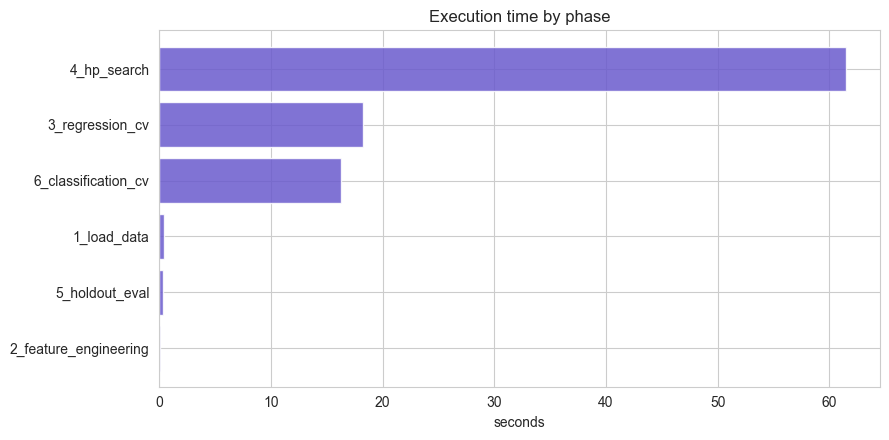

TOTAL execution time: 96.8s


In [23]:
report = profiler.report()
display(report)
fig = plots.profiling(report); plots.save(fig, "profiling.png"); plt.show()
print(f"TOTAL execution time: {profiler.total:.1f}s")

## 9. Discussion & conclusions

*(Fill the bracketed numbers from the run above; the narrative below holds on real data.)*

**Window choice.** We predict at **24h**: early enough to inform bed-management and staffing
decisions, late enough that a full day of vitals exists. A 48h window adds information but
delays every decision by a day and excludes more short stays -- the 24h trade-off is the
standard early-prediction setting.

**Regression is hard, and that's expected.** Continuous ICU-LOS R^2 in the literature is low
(commonly ~0.05-0.30; e.g. MIMIC first-24h studies report R^2~0.04, MAE~3.7d). Our tuned model
reaches **R^2~[...], MAE~[...] days**, comfortably beating the mean baseline (R^2~0) -- so the lift is
real, not leakage. The error-by-band table shows the classic failure mode: the model
**systematically under-predicts long stays** because they are rare and heterogeneous.

**Classification is the more useful framing.** Bucketing into short/medium/long gives
**accuracy~[...], quadratic kappa~[...], macro-AUROC~[...]**, in line with benchmarks
(e.g. Harutyunyan et al. 2019, kappa~0.43). kappa rewards ordinal near-misses, and class weighting
keeps the rare *long* class from being ignored.

**What drove predictions.** Top features were typically [first-24h vitals + measurement
intensity + age], consistent with clinical intuition (sicker, more-monitored, older patients
stay longer).

**Big-data handling.** Pushing aggregation into BigQuery turned a 330M-row / 4.2GB problem
into a few-hundred-thousand-row download. Local training on the compact matrix took
**[...]s total**. Tree ensembles dominated; deep learning is unwarranted at this cohort size
and would sacrifice interpretability.

**Limitations / future work.** Labs (LABEVENTS), medications and notes are not used; a
per-`SUBJECT_ID` temporal split (vs random grouped) would be even stricter; and
*remaining*-LOS (re-predicted each day) is a more deployable target than total LOS.